In [1]:
from __future__ import print_function,division
from builtins import range

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [38]:
NUM_TRIALS=10000
EPS=.1
BANDIT_PROBABILITIES=[.2,.7,.75]

In [39]:
class Bandit:
    def __init__(self,p):
        self.p=p
        self.p_estimate=1
        self.N=1
        
    def pull(self):
        return np.random.random()<self.p
    
    def update(self,x):
        self.N=self.N+1
        self.p_estimate=((self.p_estimate*(self.N-1))+x)/self.N
    

In [40]:
def expriment():
    bandits = [Bandit(p) for p in BANDIT_PROBABILITIES]
    rewards=np.zeros(NUM_TRIALS)
    
    for i in range (NUM_TRIALS):
        
        j=np.argmax([b.p_estimate for b in bandits])
        
        
        x=bandits[j].pull()
        rewards[i]=x
        bandits[j].update(x)
    
    for b in bandits:
        print("mean estimate:",b.p_estimate)
    
    print("total reward earned:",rewards.sum())
    print("overall win rate:",rewards.sum()/NUM_TRIALS)
    
    print("num times selected each bandit:",[b.N for b in bandits])
        
    cumulative_rewards=np.cumsum(rewards)
    win_rates=cumulative_rewards/(np.arange(NUM_TRIALS)+1)
    
    plt.ylim([0,1])
    plt.plot(win_rates)
    plt.plot(np.ones(NUM_TRIALS)*np.max(BANDIT_PROBABILITIES))
    plt.show()

mean estimate: 0.5
mean estimate: 0.7209302325581395
mean estimate: 0.7493472584856382
total reward earned: 7491.0
overall win rate: 0.7491
num times selected each bandit: [2, 43, 9958]


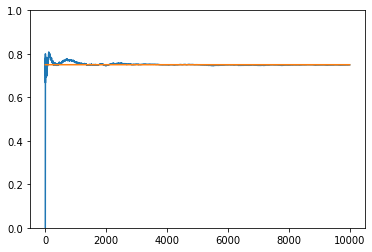

In [41]:
if __name__ =="__main__":
    expriment()